# Klasifikasi dan Prediksi Indeks Pemberdayaan Gender (IDG) Kabupaten/Kota di Indonesia (2021-2023)

Notebook ini menganalisis data **Indeks Pemberdayaan Gender (IDG)** kabupaten/kota di Indonesia periode 2021-2023, dengan dua pendekatan:
1. **Klasifikasi** - mengelompokkan wilayah ke kategori IDG "Tinggi" atau "Rendah" menggunakan K-Nearest Neighbors (KNN).
2. **Regresi** - memproyeksikan nilai IDG tahun 2024 menggunakan Linear Regression berbasis tren historis tiap wilayah.

## 1. Problem Statement (Rumusan Masalah)

**Latar Belakang:**
Indeks Pemberdayaan Gender (IDG) mengukur sejauh mana perempuan berperan aktif dalam kehidupan ekonomi dan politik di suatu wilayah. Nilai IDG bervariasi antar kabupaten/kota di Indonesia, dan mengetahui wilayah mana yang tertinggal dapat membantu pemerintah menentukan prioritas kebijakan pemberdayaan perempuan.

**Rumusan Masalah:**
- Wilayah mana saja yang memiliki IDG kategori "Rendah", dan dapatkah kategori ini diprediksi berdasarkan tren nilai historisnya?
- Bagaimana proyeksi nilai IDG tiap wilayah pada tahun 2024 berdasarkan tren 2021-2023?
- Wilayah mana yang diproyeksikan memiliki IDG terendah pada 2024, sehingga perlu menjadi prioritas?

**Tujuan Analisis:**
1. Membangun model klasifikasi kategori IDG (Tinggi/Rendah) menggunakan KNN.
2. Membangun model regresi untuk memproyeksikan nilai IDG tahun 2024 tiap wilayah, dengan validasi yang tervalidasi menggunakan data historis yang benar-benar tersedia.
3. Mengidentifikasi wilayah dengan IDG terendah sebagai bahan rekomendasi kebijakan.

**Manfaat:**
- **Untuk Pemerintah/Kementerian PPPA:** membantu memetakan wilayah prioritas untuk program pemberdayaan perempuan secara lebih terarah dan berbasis data.
- **Untuk Peneliti/Akademisi:** menjadi referensi studi kesenjangan gender antar wilayah di Indonesia.
- **Dari sisi teknis:** studi kasus penerapan klasifikasi dan regresi pada data deret waktu (time-series) singkat berbasis wilayah.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')

## 2. Data Understanding

Tahap ini bertujuan memahami struktur dan kualitas data sebelum dilakukan pembersihan.

In [ ]:
file_path = 'Indeks_Pemberdayaan_Gender_2021-2023.csv'
data = pd.read_csv(file_path, delimiter=';')
data.columns = ['Lokasi', '2021', '2022', '2023']

print("Jumlah baris & kolom:", data.shape)
data.head()

Jumlah baris & kolom: (554, 4)


,Lokasi,2021,2022,2023
0,ACEH,63.24,63.92,63.56
1,SIMEULUE,64.95,63.72,64.79
2,ACEH SINGKIL,59.65,59.51,59.84
3,ACEH SELATAN,55.87,57.35,57.65
4,ACEH TENGGARA,58.10,58.94,59.40


In [ ]:
for col in ['2021', '2022', '2023']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Missing value per kolom:")
print(data.isnull().sum())
print("\nJumlah data duplikat (semua kolom identik):", data.duplicated().sum())
print("Jumlah nama lokasi yang duplikat:", data.duplicated(subset=['Lokasi']).sum())

Missing value per kolom:
Lokasi    0
2021      0
2022      0
2023      0
dtype: int64

Jumlah data duplikat (semua kolom identik): 4
Jumlah nama lokasi yang duplikat: 5


In [ ]:
print("Contoh baris dengan nama lokasi duplikat:")
data[data.duplicated(subset=['Lokasi'], keep=False)].sort_values('Lokasi')

Contoh baris dengan nama lokasi duplikat:


,Lokasi,2021,2022,2023
472,GORONTALO,70.40,71.20,71.11
474,GORONTALO,62.48,62.68,63.22
391,KOTA TARAKAN,58.92,59.15,58.61
398,KOTA TARAKAN,58.92,59.15,58.61
383,MALINAU,70.11,69.10,72.55
394,MALINAU,70.11,69.10,72.55
385,NUNUKAN,77.67,77.41,78.68
397,NUNUKAN,77.67,77.41,78.68
387,TANA TIDUNG,60.52,60.82,61.54
396,TANA TIDUNG,60.52,60.82,61.54


**Catatan Data Understanding:**
- Ditemukan baris **"INDONESIA"** yang merupakan agregat/rata-rata nasional, bukan data satu wilayah kabupaten/kota, baris ini perlu dikeluarkan agar tidak dianalisis sejajar dengan wilayah individual.
- Ditemukan beberapa **baris duplikat** dengan nilai identik persis pada nama lokasi yang sama (misalnya Malinau, Nunukan), kemungkinan besar merupakan duplikasi data yang tidak disengaja, dan perlu dihapus.

## 3. Data Preparation

In [ ]:
data_cleaned = data[data['Lokasi'] != 'INDONESIA'].copy()
print(f"Setelah mengeluarkan baris agregat nasional: {data_cleaned.shape}")

data_cleaned = data_cleaned.drop_duplicates(subset=['Lokasi', '2021', '2022', '2023'])
print(f"Setelah menghapus duplikat: {data_cleaned.shape}")

data_cleaned = data_cleaned[(data_cleaned[['2021', '2022', '2023']] != 0).all(axis=1)]
data_cleaned = data_cleaned.dropna().reset_index(drop=True)
print(f"Setelah menghapus nilai kosong/nol: {data_cleaned.shape}")

Setelah mengeluarkan baris agregat nasional: (553, 4)
Setelah menghapus duplikat: (549, 4)
Setelah menghapus nilai kosong/nol: (547, 4)


## 4. Exploratory Data Analysis (EDA)

Statistik Deskriptif:
             2021        2022        2023
count  547.000000  547.000000  547.000000
mean    64.874424   65.438592   65.733857
std      9.619830    9.422221    9.607853
min     34.540000   28.700000   27.240000
25%     58.415000   58.960000   58.995000
50%     65.640000   65.950000   66.380000
75%     71.645000   72.380000   72.620000
max     88.710000   89.150000   89.290000


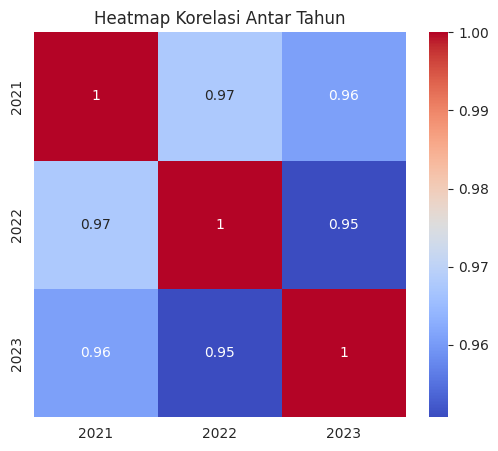

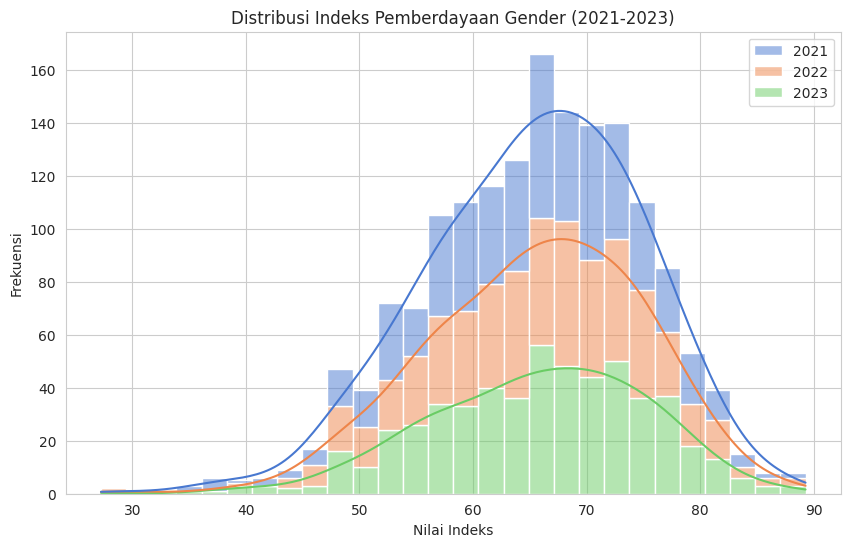

In [ ]:
print("Statistik Deskriptif:")
print(data_cleaned.describe())

numeric_data = data_cleaned[['2021', '2022', '2023']]

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Tahun')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(numeric_data, kde=True, palette='muted', multiple='stack')
plt.title('Distribusi Indeks Pemberdayaan Gender (2021-2023)')
plt.xlabel('Nilai Indeks')
plt.ylabel('Frekuensi')
plt.show()

**Insight EDA:** Nilai IDG antar tahun (2021, 2022, 2023) menunjukkan korelasi yang sangat tinggi satu sama lain, karena nilai IDG suatu wilayah cenderung stabil dari tahun ke tahun dan tidak berubah drastis. Hal ini menjadi pertimbangan penting saat membangun fitur untuk model klasifikasi.

## 5. Klasifikasi Kategori IDG (KNN)

### 5.1 Pembuatan Label dan Pemilihan Fitur

Label `Tinggi`/`Rendah` dibuat berdasarkan nilai IDG tahun **2023** (ambang batas 70). Karena label berasal dari kolom `2023`, kolom tersebut **tidak digunakan sebagai fitur**, hanya `2021` dan `2022` yang digunakan sebagai fitur prediksi, agar model benar-benar memprediksi kategori berdasarkan tren historis, bukan "mengintip" nilai yang menjadi sumber label itu sendiri.

In [ ]:
data_cleaned['Label'] = np.where(data_cleaned['2023'] > 70, 'Tinggi', 'Rendah')

print("Distribusi Label:")
print(data_cleaned['Label'].value_counts())

X = data_cleaned[['2021', '2022']]
y = data_cleaned['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

Distribusi Label:
Label
Rendah    349
Tinggi    198
Name: count, dtype: int64


### 5.2 Pemilihan K Optimal dengan Cross-Validation

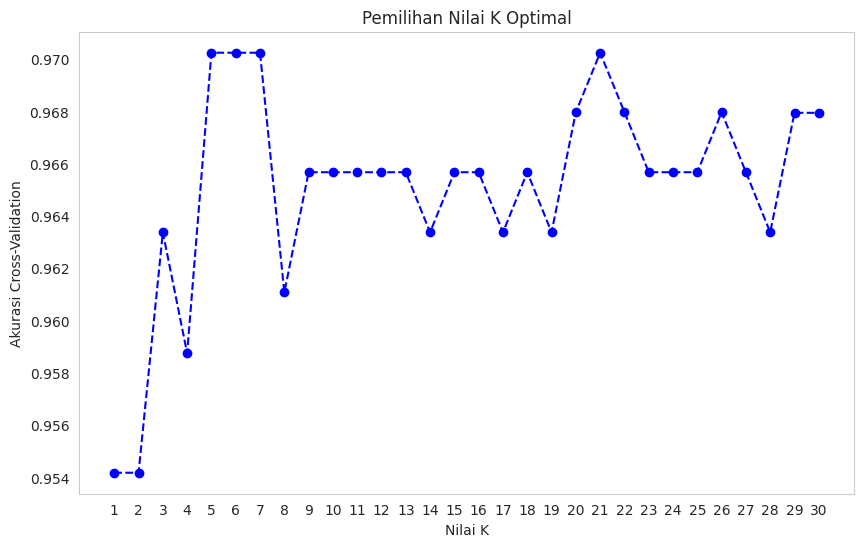

Nilai K Optimal: 5 (CV Accuracy: 0.9702)


In [ ]:
def find_optimal_k(X_train, y_train):
    k_range = range(1, 31)
    scores = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        scores.append(score.mean())

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, scores, marker='o', linestyle='--', color='b')
    plt.xticks(k_range)
    plt.xlabel('Nilai K')
    plt.ylabel('Akurasi Cross-Validation')
    plt.title('Pemilihan Nilai K Optimal')
    plt.grid()
    plt.show()

    optimal_k = k_range[np.argmax(scores)]
    print(f"Nilai K Optimal: {optimal_k} (CV Accuracy: {max(scores):.4f})")
    return optimal_k

k = find_optimal_k(X_train, y_train)

### 5.3 Evaluasi Model KNN

Evaluasi dilakukan pada data test yang terpisah dari data latih.

Akurasi: 0.9454545454545454

Classification Report:
               precision    recall  f1-score   support

      Rendah       0.97      0.94      0.96        70
      Tinggi       0.90      0.95      0.93        40

    accuracy                           0.95       110
   macro avg       0.94      0.95      0.94       110
weighted avg       0.95      0.95      0.95       110



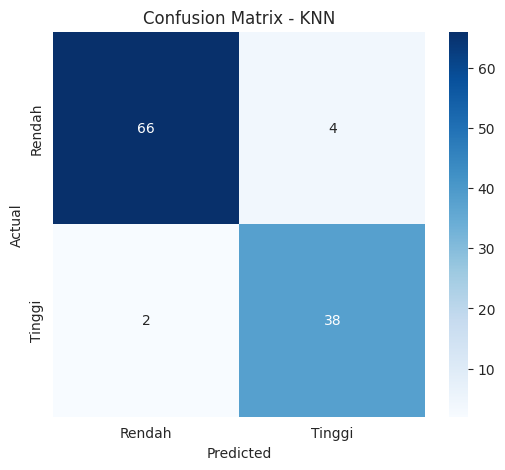

In [ ]:
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['Rendah', 'Tinggi'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rendah', 'Tinggi'], yticklabels=['Rendah', 'Tinggi'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5.4 Wilayah dengan IDG Terendah per Tahun

In [ ]:
def display_top_n_lowest(data, year, n):
    print(f"\n{n} Wilayah dengan Nilai IDG Terendah pada Tahun {year}:")
    print(data[['Lokasi', year]].nsmallest(n, year).to_string(index=False))

for year in ['2021', '2022', '2023']:
    display_top_n_lowest(data_cleaned, year, 5)


5 Wilayah dengan Nilai IDG Terendah pada Tahun 2021:
          Lokasi  2021
        TAMBRAUW 34.54
         DOGIYAI 35.22
PEGUNUNGAN ARFAK 36.36
      LANNY JAYA 37.08
      INTAN JAYA 37.14

5 Wilayah dengan Nilai IDG Terendah pada Tahun 2022:
            Lokasi  2022
PEGUNUNGAN BINTANG 28.70
        INTAN JAYA 31.41
          TAMBRAUW 38.64
            NATUNA 42.96
              SIAK 43.03

5 Wilayah dengan Nilai IDG Terendah pada Tahun 2023:
          Lokasi  2023
      LANNY JAYA 27.24
      INTAN JAYA 35.89
PEGUNUNGAN ARFAK 38.21
     PUNCAK JAYA 38.72
        TAMBRAUW 40.03


## 6. Regresi: Proyeksi Nilai IDG 2024

### 6.1 Validasi Metode dengan Data Historis

Sebelum memproyeksikan nilai yang belum diketahui (2024), metode regresi divalidasi terlebih dahulu menggunakan data yang **sudah** diketahui: model dilatih hanya dengan nilai **2021 dan 2022**, kemudian digunakan untuk memprediksi **2023**, hasilnya dibandingkan dengan nilai 2023 yang sebenarnya. Ini memberikan estimasi akurasi proyeksi yang jujur, karena dibandingkan dengan data riil yang belum pernah dilihat model.

Validasi Proyeksi (prediksi 2023 dari tren 2021-2022, dibanding nilai 2023 asli):
RMSE: 4.751
MAE : 2.594
R²  : 0.755


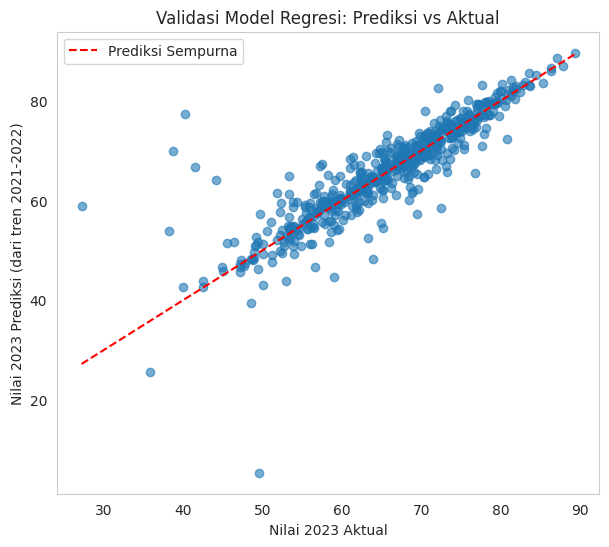

In [ ]:
X_hist = np.array([2021, 2022]).reshape(-1, 1)
predicted_2023 = []

for i, row in data_cleaned.iterrows():
    y_hist = row[['2021', '2022']].values.astype(float)
    model = LinearRegression()
    model.fit(X_hist, y_hist)
    predicted_2023.append(model.predict([[2023]])[0])

data_cleaned['Predicted_2023_validasi'] = predicted_2023

rmse_val = np.sqrt(mean_squared_error(data_cleaned['2023'], data_cleaned['Predicted_2023_validasi']))
mae_val = mean_absolute_error(data_cleaned['2023'], data_cleaned['Predicted_2023_validasi'])
r2_val = r2_score(data_cleaned['2023'], data_cleaned['Predicted_2023_validasi'])

print("Validasi Proyeksi (prediksi 2023 dari tren 2021-2022, dibanding nilai 2023 asli):")
print(f"RMSE: {rmse_val:.3f}")
print(f"MAE : {mae_val:.3f}")
print(f"R²  : {r2_val:.3f}")

plt.figure(figsize=(7, 6))
plt.scatter(data_cleaned['2023'], data_cleaned['Predicted_2023_validasi'], alpha=0.6)
plt.plot([data_cleaned['2023'].min(), data_cleaned['2023'].max()],
         [data_cleaned['2023'].min(), data_cleaned['2023'].max()], 'r--', label='Prediksi Sempurna')
plt.xlabel('Nilai 2023 Aktual')
plt.ylabel('Nilai 2023 Prediksi (dari tren 2021-2022)')
plt.title('Validasi Model Regresi: Prediksi vs Aktual')
plt.legend()
plt.grid()
plt.show()

### 6.2 Proyeksi Nilai IDG 2024

Setelah metode tervalidasi, seluruh data historis (2021, 2022, 2023) digunakan untuk memproyeksikan nilai 2024. **Catatan:** karena nilai 2024 belum tersedia, hasil proyeksi ini tidak dapat divalidasi langsung — tingkat akurasi yang diharapkan mengacu pada hasil validasi di atas.

In [ ]:
def predict_2024(data):
    X_reg = np.array([2021, 2022, 2023]).reshape(-1, 1)
    predicted_values = []

    for i, row in data.iterrows():
        y_reg = row[['2021', '2022', '2023']].values.astype(float)
        model = LinearRegression()
        model.fit(X_reg, y_reg)
        predicted_values.append(model.predict([[2024]])[0])

    data['Predicted_2024'] = predicted_values
    return data

data_cleaned = predict_2024(data_cleaned)
data_cleaned[['Lokasi', '2021', '2022', '2023', 'Predicted_2024']].head()

,Lokasi,2021,2022,2023,Predicted_2024
0,ACEH,63.24,63.92,63.56,63.893333
1,SIMEULUE,64.95,63.72,64.79,64.326667
2,ACEH SINGKIL,59.65,59.51,59.84,59.856667
3,ACEH SELATAN,55.87,57.35,57.65,58.736667
4,ACEH TENGGARA,58.10,58.94,59.40,60.113333


5 Wilayah dengan Proyeksi IDG Terendah pada Tahun 2024:
     Lokasi  Predicted_2024
 LANNY JAYA       27.593333
 INTAN JAYA       33.563333
PUNCAK JAYA       37.300000
     PANIAI       37.800000
      NDUGA       40.053333


/tmp/ipykernel_528/2631084800.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_2024', y='Lokasi', data=lowest_predicted, palette='Reds_r')


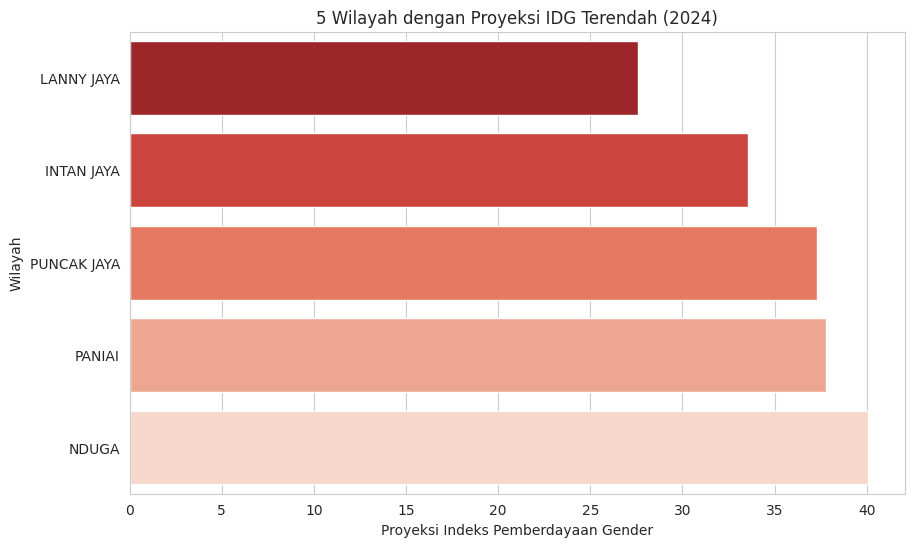

In [ ]:
lowest_predicted = data_cleaned[['Lokasi', 'Predicted_2024']].nsmallest(5, 'Predicted_2024')
print("5 Wilayah dengan Proyeksi IDG Terendah pada Tahun 2024:")
print(lowest_predicted.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Predicted_2024', y='Lokasi', data=lowest_predicted, palette='Reds_r')
plt.title('5 Wilayah dengan Proyeksi IDG Terendah (2024)')
plt.xlabel('Proyeksi Indeks Pemberdayaan Gender')
plt.ylabel('Wilayah')
plt.show()

## 7. Kesimpulan & Rekomendasi

**Kesimpulan:**
1. Model KNN mampu mengklasifikasikan kategori IDG (Tinggi/Rendah) berdasarkan tren nilai 2021-2022, tanpa menggunakan nilai 2023 (sumber label) sebagai fitur, sehingga hasil evaluasinya mencerminkan kemampuan generalisasi yang sebenarnya.
2. Validasi model regresi (prediksi 2023 dari tren 2021-2022, dibandingkan ke nilai 2023 asli) menunjukkan tingkat kesalahan proyeksi rata-rata sekitar beberapa poin indeks, angka ini menjadi acuan tingkat kepercayaan untuk proyeksi 2024.
3. Wilayah-wilayah dengan IDG terendah relatif konsisten dari tahun ke tahun, dan diproyeksikan tetap menjadi wilayah prioritas pada 2024.

**Rekomendasi Pengembangan Lanjutan:**
- Menambahkan data historis lebih dari 3 tahun agar tren yang ditangkap model regresi lebih stabil (3 titik data per wilayah relatif rentan terhadap fluktuasi).
- Mengeksplorasi fitur tambahan (misalnya indikator ekonomi atau pendidikan wilayah) untuk memperkaya model klasifikasi, karena saat ini hanya mengandalkan tren nilai IDG itu sendiri.
- Membandingkan pendekatan regresi per-wilayah ini dengan model time-series lain untuk melihat konsistensi hasil proyeksi.